# Interferometric Reflectivity Dip: visualisation of the beam narrowing effect as function of the index under the gold


In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft2, fftshift, ifft2
from scipy.integrate import trapezoid
import PyMoosh as PM
import my_module as my_mod
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing
# if you want to use a GPU in addition of the CPU
# import torch
# device = torch.device("mps")  # GPU Apple (Metal)

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

# define the number of CPU core to use for multiprocessing
total_cores = multiprocessing.cpu_count()
reserved_cores = 4  # number of CPU core reserved for the system
n_jobs = max(1, total_cores - reserved_cores)

Global initialisation of the parameters.

In [2]:
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
inc = 44.37
w = 66573
wx = w
wy = w
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

k0 = 2 * np.pi / wavelength
n2 = 1.515
kz = np.sqrt((n2 * k0)**2 - A**2 - B**2)

theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc)))**2 + B**2) / (n2 * k0))

The index under the gold varies around the value of air (1.00) to see the effect on the beam narrowing.

In [3]:
n_under_gold_list = np.arange(0.99, 1.01, 0.00005)

Function to parallelize the computations and run.

In [4]:
def process_n(wavelength, theta, w, n_under_gold, A, X, Y, x, y):
    # definition of the structure on which the reflection is done
    # get the material from refractiveindex database (RII) when possible
    Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
    Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
    stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
    thickness = [4000, 2, 47, 1000]  # thickness of each layer
    mat = ["BK7",Cr,Au,n_under_gold**2]
    structure = PM.Structure(mat, stack, thickness, verbose=False)   
    cr = np.zeros_like(A, dtype=complex)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
            if (i == N and j == N):
                R_central = R  # Store the reflectivity for the central plane wave
    wx=w
    wy=w
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
    U1ki=cr*U1k # spectral beam after reflection
    U1i=ifft2(U1ki) # spatial beam after reflection
    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    # determination of the shift
    decx=bxU1i-bxU1
    decy=byU1i-byU1
    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    # save of the shifts and enlargements
    return n_under_gold, elarrelatx, elarrelaty, decx, decy, R_central

# parallel computation (on inc)
results = Parallel(n_jobs=n_jobs, backend="loky")(delayed(process_n)(wavelength, theta, w, n_under_gold, A, X, Y, x, y) for n_under_gold in tqdm(n_under_gold_list, desc="Scan of all the indices"))

# build the final arrays
ELx = np.zeros((len(n_under_gold_list)))
ELy = np.zeros((len(n_under_gold_list)))
DECx = np.zeros((len(n_under_gold_list)))
DECy = np.zeros((len(n_under_gold_list)))
R_central = np.zeros((len(n_under_gold_list)))

n_index = {val: idx for idx, val in enumerate(n_under_gold_list)}

for n_under_gold, ELx_val, ELy_val, DECx_val, DECy_val, R_val in results:
    i = n_index[n_under_gold]
    ELx[i] = ELx_val
    ELy[i] = ELy_val
    DECx[i] =DECx_val
    DECy[i] =DECy_val
    R_central[i] = R_val

Scan of all the indices: 100%|██████████| 401/401 [01:38<00:00,  4.08it/s]


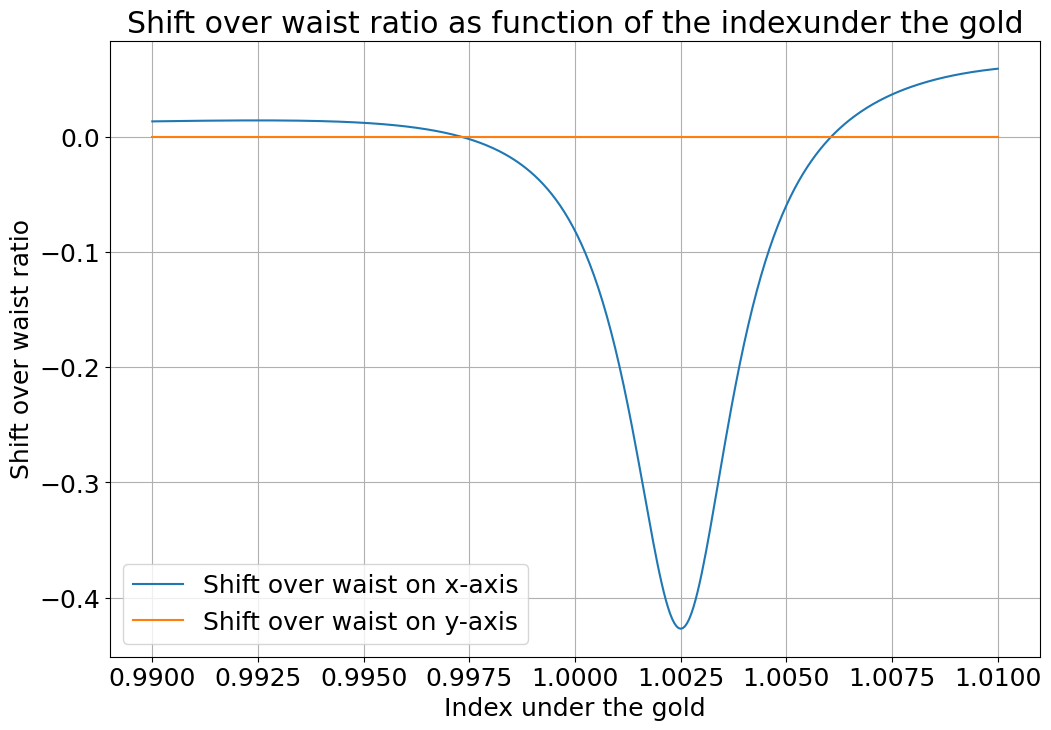

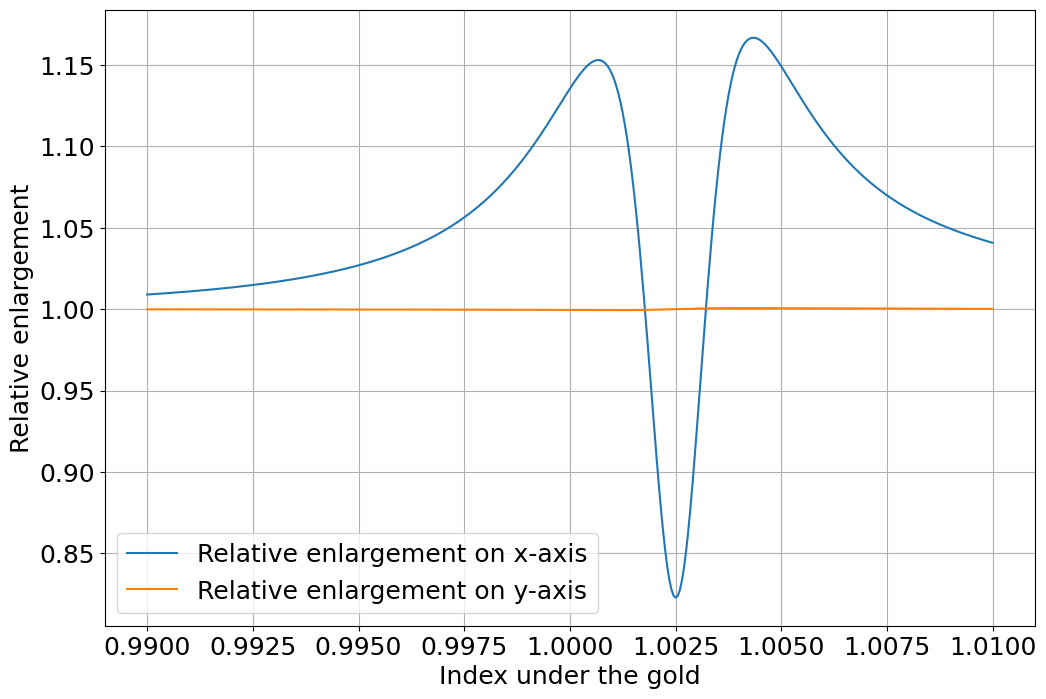

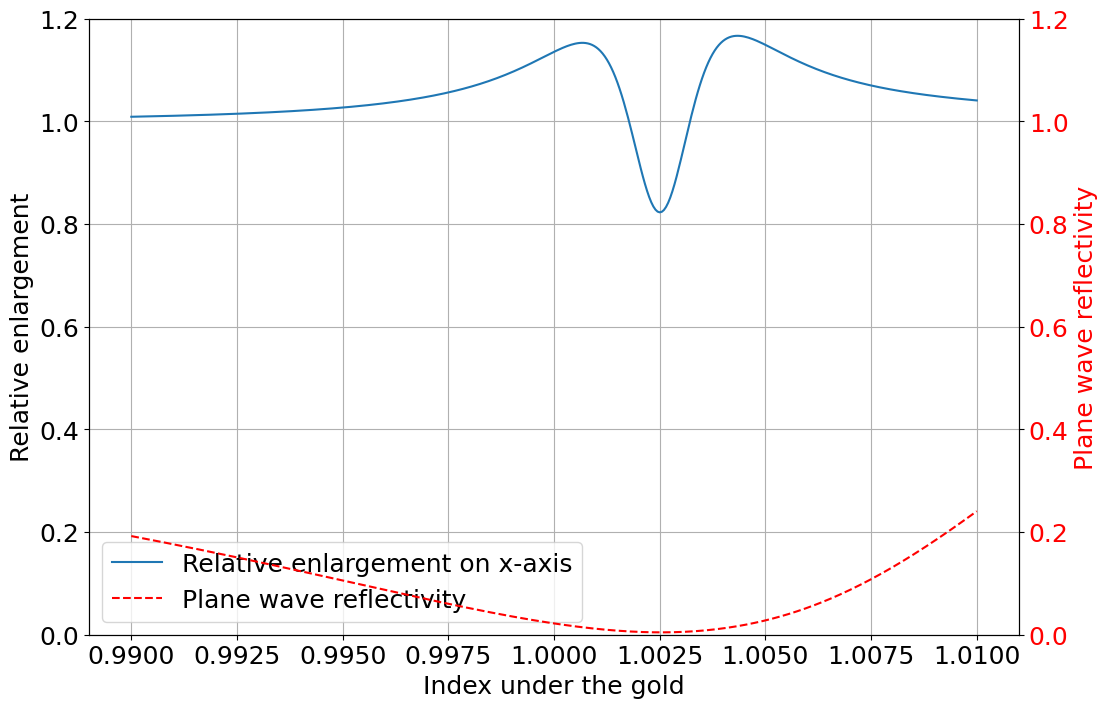

In [5]:
plt.figure(figsize=(12,8))
plt.plot(n_under_gold_list, DECx/w, label="Shift over waist on x-axis")
plt.plot(n_under_gold_list, DECy/w, label="Shift over waist on y-axis")
plt.title(f"Shift over waist ratio as function of the indexunder the gold")
plt.xlabel("Index under the gold")
plt.ylabel("Shift over waist ratio")
plt.grid()
plt.legend()
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/extra_plots/shifts_over_w_f_n_under_gold.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(n_under_gold_list, ELx, label="Relative enlargement on x-axis")
plt.plot(n_under_gold_list, ELy, label="Relative enlargement on y-axis")
# plt.title(f"Relative enlargements vs index under the gold")
plt.xlabel("Index under the gold")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/extra_plots/rel_enlargement_f_n_under_gold.{file_ext}", bbox_inches="tight")

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.plot(n_under_gold_list, ELx, label="Relative enlargement on x-axis")
# ax1.plot(n_under_gold_list, ELy, label="Relative enlargement on y-axis")
ax1.set_ylim(0,1.20)
ax1.set_xlabel("Index under the gold")
ax1.set_ylabel("Relative enlargement")
ax1.grid()
ax2 = ax1.twinx()
ax2.plot(n_under_gold_list, R_central, 'r--', label="Plane wave reflectivity")
ax2.set_ylim(0,1.20)
ax2.set_ylabel("Plane wave reflectivity", color='r')
ax2.tick_params(axis='y', labelcolor='r')
# plt.title(f"Relative enlargements vs incidence ({w:.0f} nm waist)")
# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/extra_plots/rel_enlargement_and_R_f_n_under_gold.{file_ext}", bbox_inches="tight")
